In [1]:
import pandas as pd

df = pd.read_csv('Housing.csv')

print(df.head(10))

rows, columns = df.shape
print("Rows:", rows)
print("Columns:", columns)

target_column = 'Price'
feature_columns = [col for col in df.columns if col != target_column]

print("Target:", target_column)
print("Features:", feature_columns)

print(df.isnull().sum())

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv("Housing.csv")
print("Original Shape:", df.shape)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Treatment:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

target = "price"  
print("\nColumns:")
print(df.columns)

categorical_cols = df.select_dtypes(include=['object', 'string']).columns


categorical_cols = [col for col in categorical_cols if col != target]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

columns_to_drop = []

for col in df.columns:
    if 'id' in col.lower():
        columns_to_drop.append(col)

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

X = df.drop(target, axis=1)
y = df[target]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFinal Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Original Shape: (545, 13)

Missing Values After Treatment:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows: 0
Shape After Removing Duplicates: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

Features Shape: (545, 13)
Target Shape: (545,)

Final Dataset Shape: (545, 14)

First 5 Rows:
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2   

In [5]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('price', axis=1)
y = df['price']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)


In [8]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression
MAE : 970043.4039201636
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


In [10]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random forest model trained successfully!")

Random forest model trained successfully!


In [11]:
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [12]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

print(comparison)

               Model           MAE          RMSE  R² Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


In [13]:
if rf_r2 > lr_r2:
    print("Random Forest performs better.")
else:
    print("Linear Regression performs better.")

Linear Regression performs better.


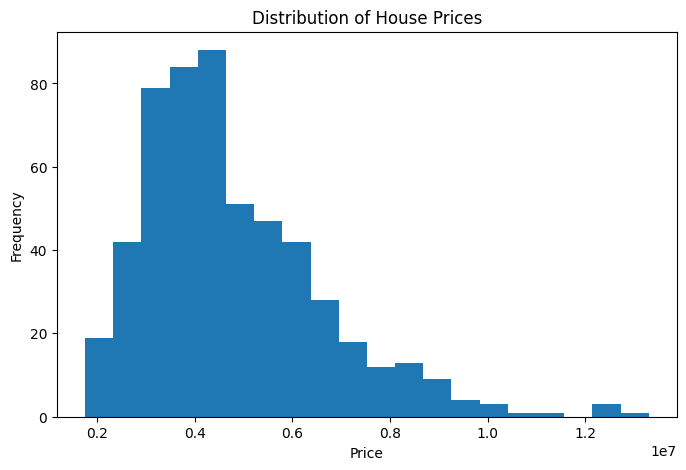

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig('histogram_price.png', bbox_inches='tight')
plt.show()

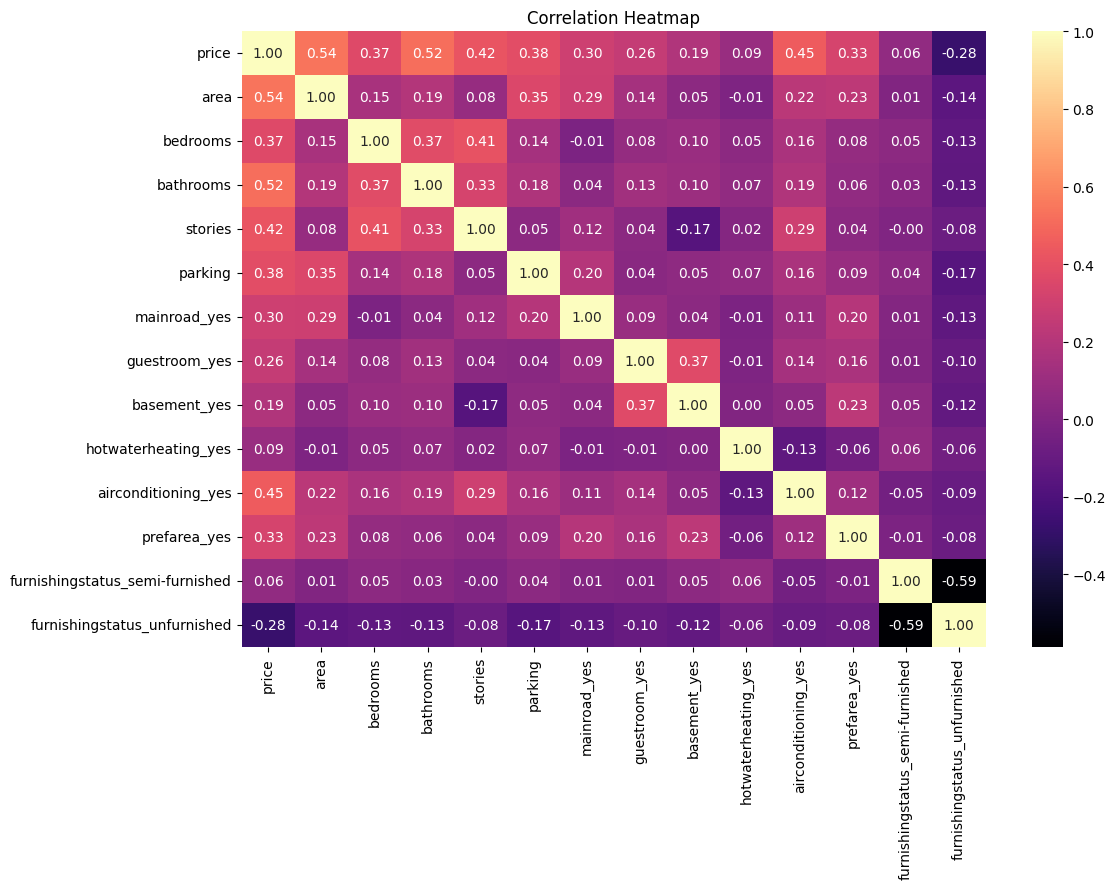

In [19]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='magma',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

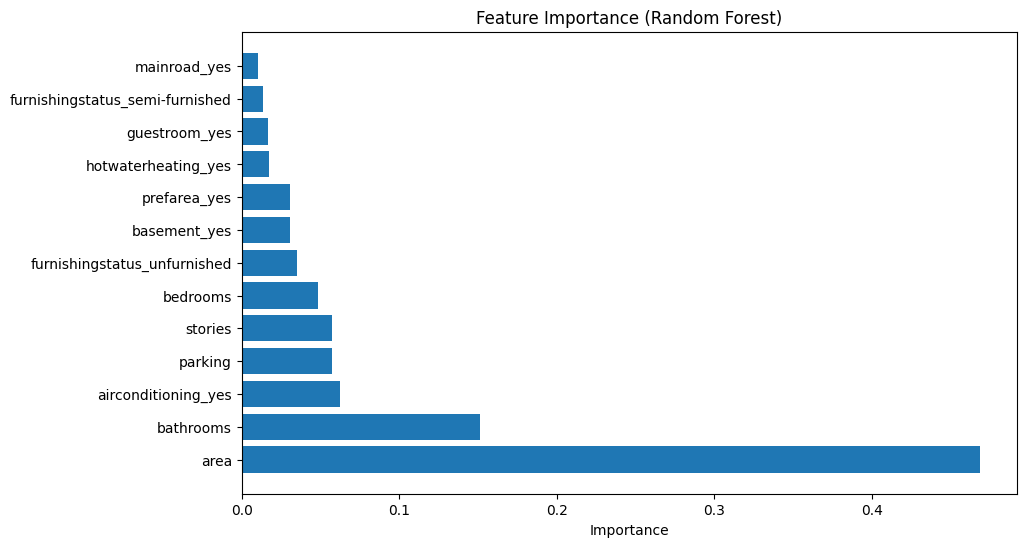

In [20]:
import pandas as pd
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

Insights & Summary

The analysis showed that area, number of bathrooms, number of stories, and air conditioning were among the most influential factors affecting house prices. The Linear Regression model achieved an R² score of approximately 0.65, which means it was able to explain about 65% of the variation in house prices and provided reasonably accurate predictions. One interesting observation was that amenities such as air conditioning and preferred location had a stronger impact on price than expected. It was also surprising that the Random Forest model did not outperform the Linear Regression model on this dataset. Based on these findings, a real estate business should focus on properties with larger areas, multiple bathrooms, and desirable amenities such as basic furniture and electronics, as these features significantly increase property value and buyer interest.